In [1]:
# Phase 3 – EDA | Cell 1: Setup + Load

from pathlib import Path
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = Path(r"D:\univercity\omid_project\economics_project")

OUT_DIR  = PROJECT / "outputs" / "phase3"
OUT_DATA = OUT_DIR / "data"
OUT_TAB  = OUT_DIR / "tables"
OUT_FIG  = OUT_DIR / "figures"

for d in [OUT_DATA, OUT_TAB, OUT_FIG]:
    d.mkdir(parents=True, exist_ok=True)

print("=" * 60)
print("Phase 3 – Exploratory Data Analysis | Cell 1")
print("=" * 60)
print(f"Timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Project Root : {PROJECT}")
print(f"Outputs      : {OUT_DIR}")

panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")

print(f"\nLoaded panel: {panel.shape}")
print(f"Countries   : {panel['country'].nunique()}")
print(f"Year range  : {panel['year'].min()} – {panel['year'].max()}")
print(f"Sample cols : {list(panel.columns[:12])}")

print("\nCell 1 completed successfully.")

Phase 3 – Exploratory Data Analysis | Cell 1
Timestamp    : 2026-09-25 20:43:11
Project Root : D:\univercity\omid_project\economics_project
Outputs      : D:\univercity\omid_project\economics_project\outputs\phase3

Loaded panel: (378, 75)
Countries   : 18
Year range  : 2000 – 2020
Sample cols : ['year', 'country', 'iso2', 'iso3', 'pop', 'rgdpmad', 'rgdpbarro', 'gdp', 'iy', 'cpi', 'stir', 'ltrate']

Cell 1 completed successfully.


Phase 3 – EDA | Cell 2: Distributions
--- Descriptive Statistics ---
                        count          mean           std           min           25%           50%           75%           max   skew  kurtosis
rgdpmad                 378.0  2.354253e+04  4.645586e+03  1.347290e+04  2.125685e+04  2.363647e+04  2.584831e+04  4.588757e+04  0.615     2.753
gdp                     378.0  1.278571e+07  3.888669e+07  4.949380e+02  5.078684e+03  7.127567e+05  3.121220e+06  2.070466e+08  3.781    13.315
cpi                     378.0  1.548220e+02  2.643600e+01  1.054470e+02  1.337010e+02  1.529260e+02  1.716270e+02  2.268250e+02  0.443    -0.174
stir                    378.0  1.601000e+00  1.879000e+00 -2.000000e+00  6.000000e-02  9.620000e-01  3.079000e+00  7.022000e+00  0.694    -0.567
ltrate                  378.0  3.068000e+00  1.935000e+00 -5.250000e-01  1.450000e+00  3.298000e+00  4.410000e+00  1.054800e+01  0.254     0.212
debtgdp                 378.0  7.410000e-01  4.290000e-01  9.

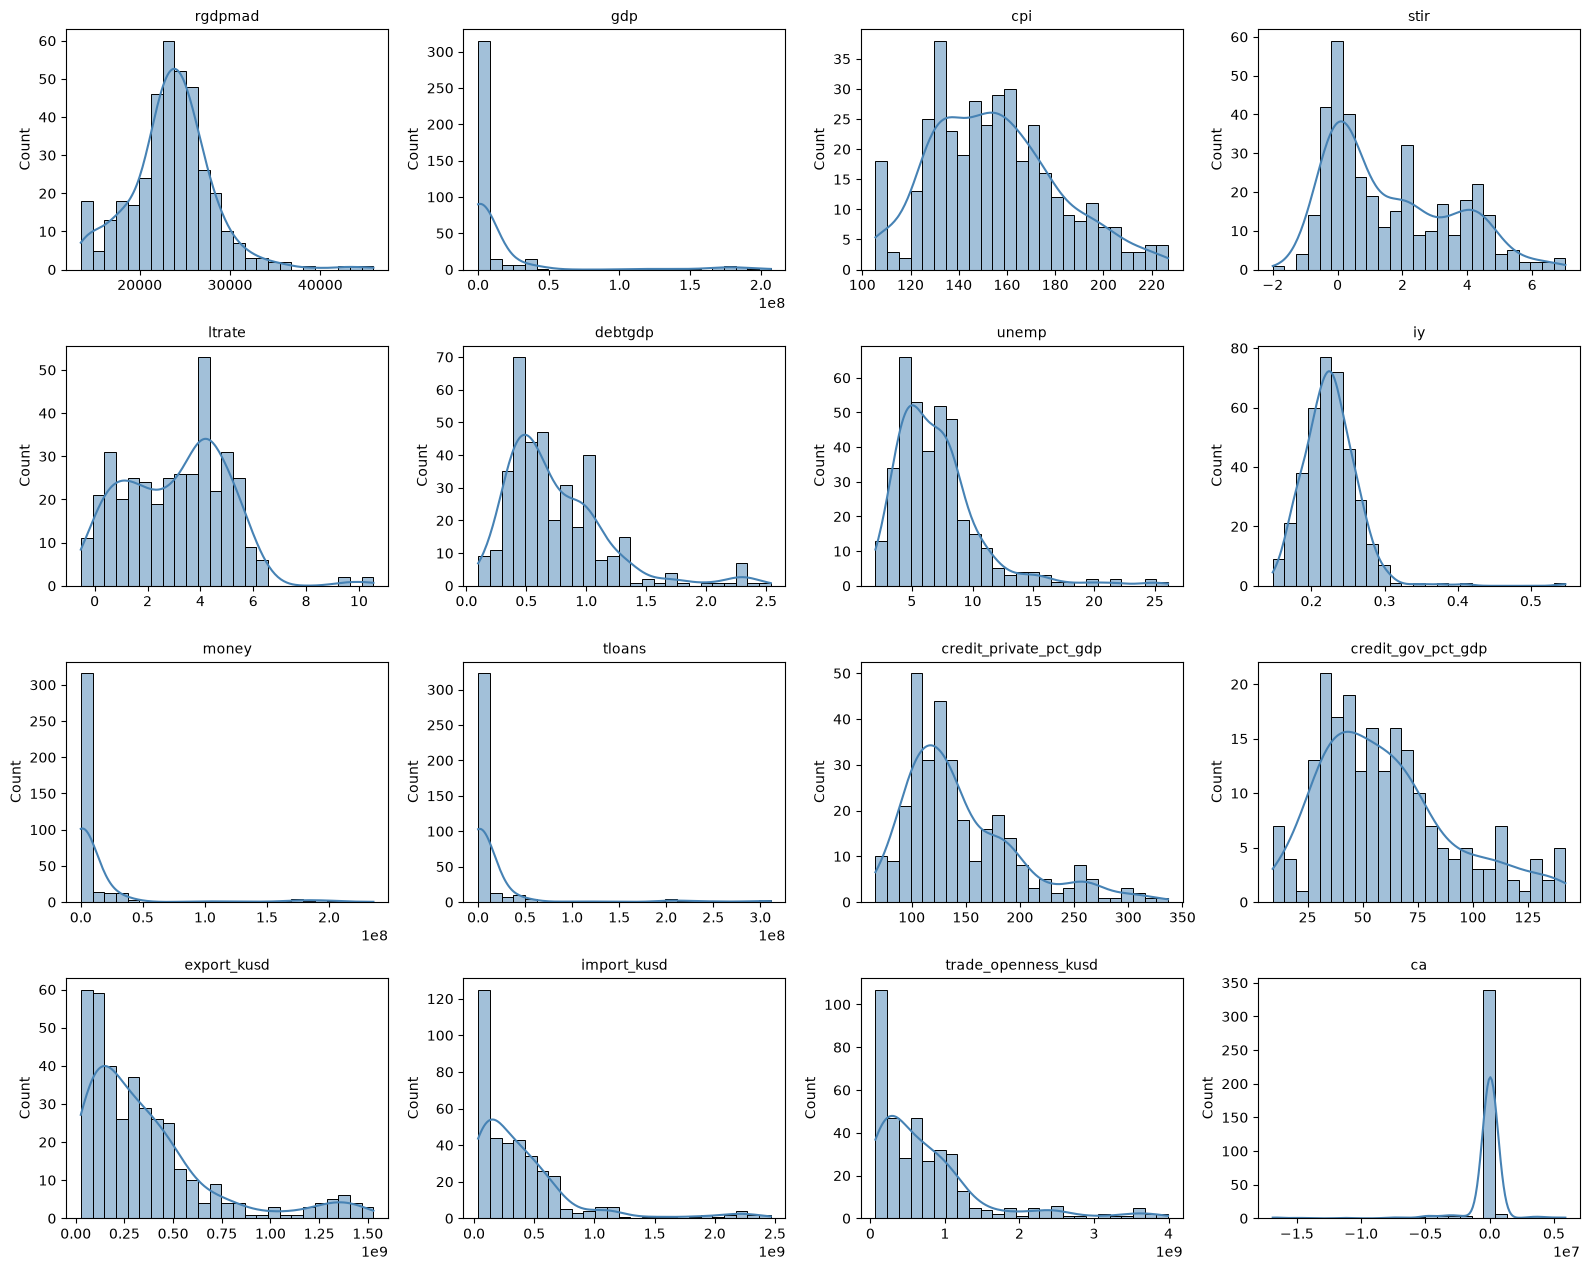

Saved figure → D:\univercity\omid_project\economics_project\outputs\phase3\figures\distributions_hist_kde.png

Cell 2 completed successfully.


In [2]:
# Phase 3 – EDA | Cell 2: Descriptive Stats + Distributions

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase3" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"
OUT_DATA = PROJECT / "outputs" / "phase3" / "data"

print("=" * 60)
print("Phase 3 – EDA | Cell 2: Distributions")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")

key_vars = [c for c in [
    "rgdpmad", "gdp", "cpi", "stir", "ltrate", "debtgdp", "unemp", "iy",
    "money", "tloans", "credit_private_pct_gdp", "credit_gov_pct_gdp",
    "export_kusd", "import_kusd", "trade_openness_kusd", "ca"
] if c in panel.columns]

desc = panel[key_vars].describe().T
desc["skew"] = panel[key_vars].skew()
desc["kurtosis"] = panel[key_vars].kurtosis()
print("--- Descriptive Statistics ---")
print(desc.round(3).to_string())
desc.to_csv(OUT_TAB / "descriptive_stats.csv")

# Hist + KDE
n = len(key_vars)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.2 * nrows))
axes = axes.flatten()

for i, col in enumerate(key_vars):
    ax = axes[i]
    s = panel[col].dropna()
    sns.histplot(s, kde=True, ax=ax, color="steelblue", bins=25)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
fig.savefig(OUT_FIG / "distributions_hist_kde.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure → {OUT_FIG / 'distributions_hist_kde.png'}")

print("\nCell 2 completed successfully.")

Phase 3 – EDA | Cell 3: Correlation
--- Correlation Matrix ---
                        rgdpmad    gdp    cpi   stir  ltrate  debtgdp  unemp     iy  money  tloans  credit_private_pct_gdp  credit_gov_pct_gdp  export_kusd  import_kusd  trade_openness_kusd     ca
rgdpmad                   1.000 -0.432 -0.128 -0.103  -0.283   -0.236 -0.436  0.411 -0.415  -0.409                   0.198              -0.347        0.190        0.284                0.248  0.245
gdp                      -0.432  1.000  0.427 -0.058   0.057    0.032  0.648 -0.016  0.995   0.974                   0.083               0.428       -0.134       -0.091               -0.112 -0.392
cpi                      -0.128  0.427  1.000 -0.287  -0.107    0.002  0.445 -0.222  0.429   0.411                   0.320               0.519       -0.024        0.057                0.023 -0.102
stir                     -0.103 -0.058 -0.287  1.000   0.737   -0.401 -0.185  0.085 -0.074  -0.049                  -0.156              -0.495       

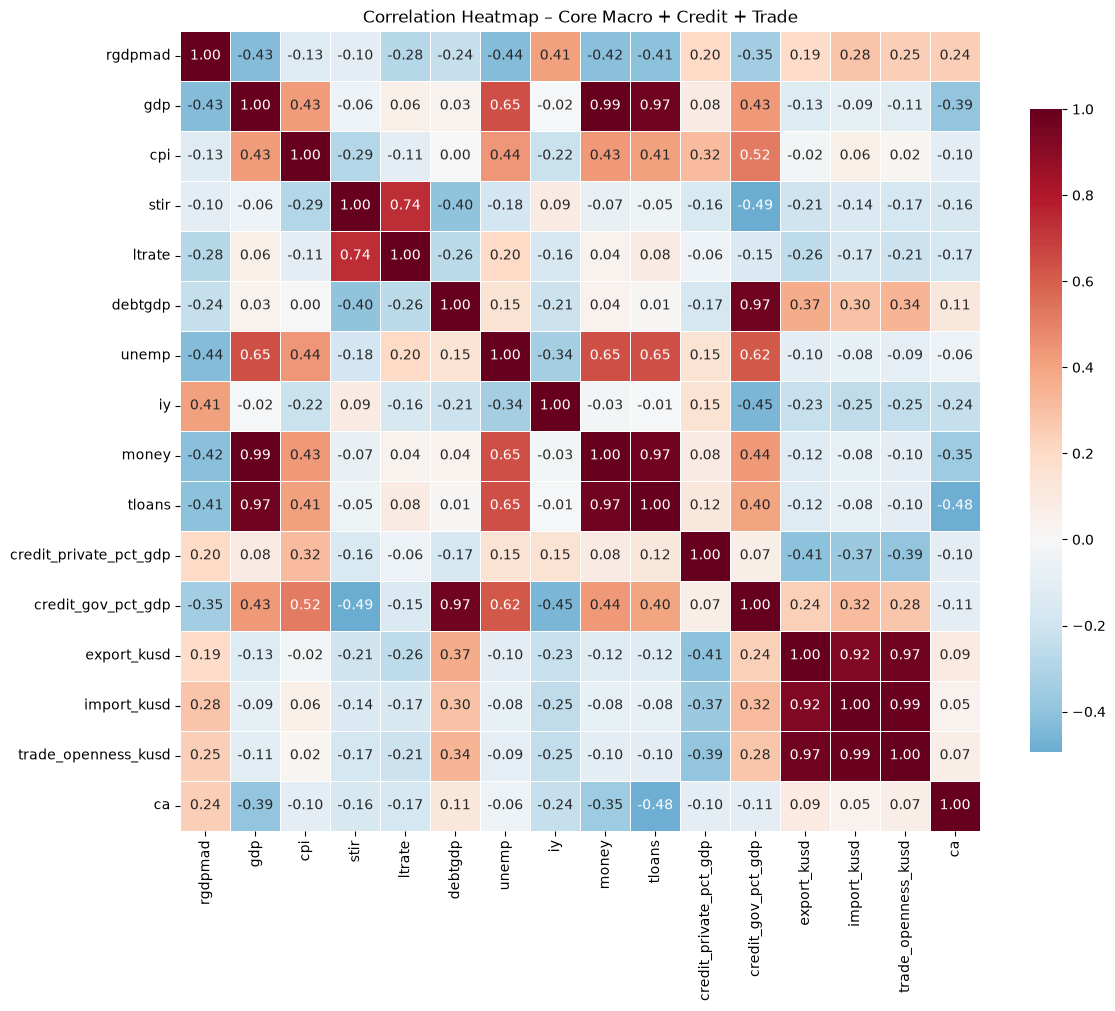

Saved → D:\univercity\omid_project\economics_project\outputs\phase3\figures\correlation_heatmap.png

Cell 3 completed successfully.


In [3]:
# Phase 3 – EDA | Cell 3: Correlation Analysis

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_TAB = PROJECT / "outputs" / "phase3" / "tables"
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"

print("=" * 60)
print("Phase 3 – EDA | Cell 3: Correlation")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")

corr_vars = [c for c in [
    "rgdpmad", "gdp", "cpi", "stir", "ltrate", "debtgdp", "unemp", "iy",
    "money", "tloans", "credit_private_pct_gdp", "credit_gov_pct_gdp",
    "export_kusd", "import_kusd", "trade_openness_kusd", "ca"
] if c in panel.columns]

corr = panel[corr_vars].corr()
print("--- Correlation Matrix ---")
print(corr.round(3).to_string())
corr.to_csv(OUT_TAB / "correlation_matrix.csv")

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            square=True, linewidths=0.4, cbar_kws={"shrink": 0.8})
plt.title("Correlation Heatmap – Core Macro + Credit + Trade")
plt.tight_layout()
plt.savefig(OUT_FIG / "correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_FIG / 'correlation_heatmap.png'}")

print("\nCell 3 completed successfully.")

Phase 3 – EDA | Cell 4: Time Series Trends


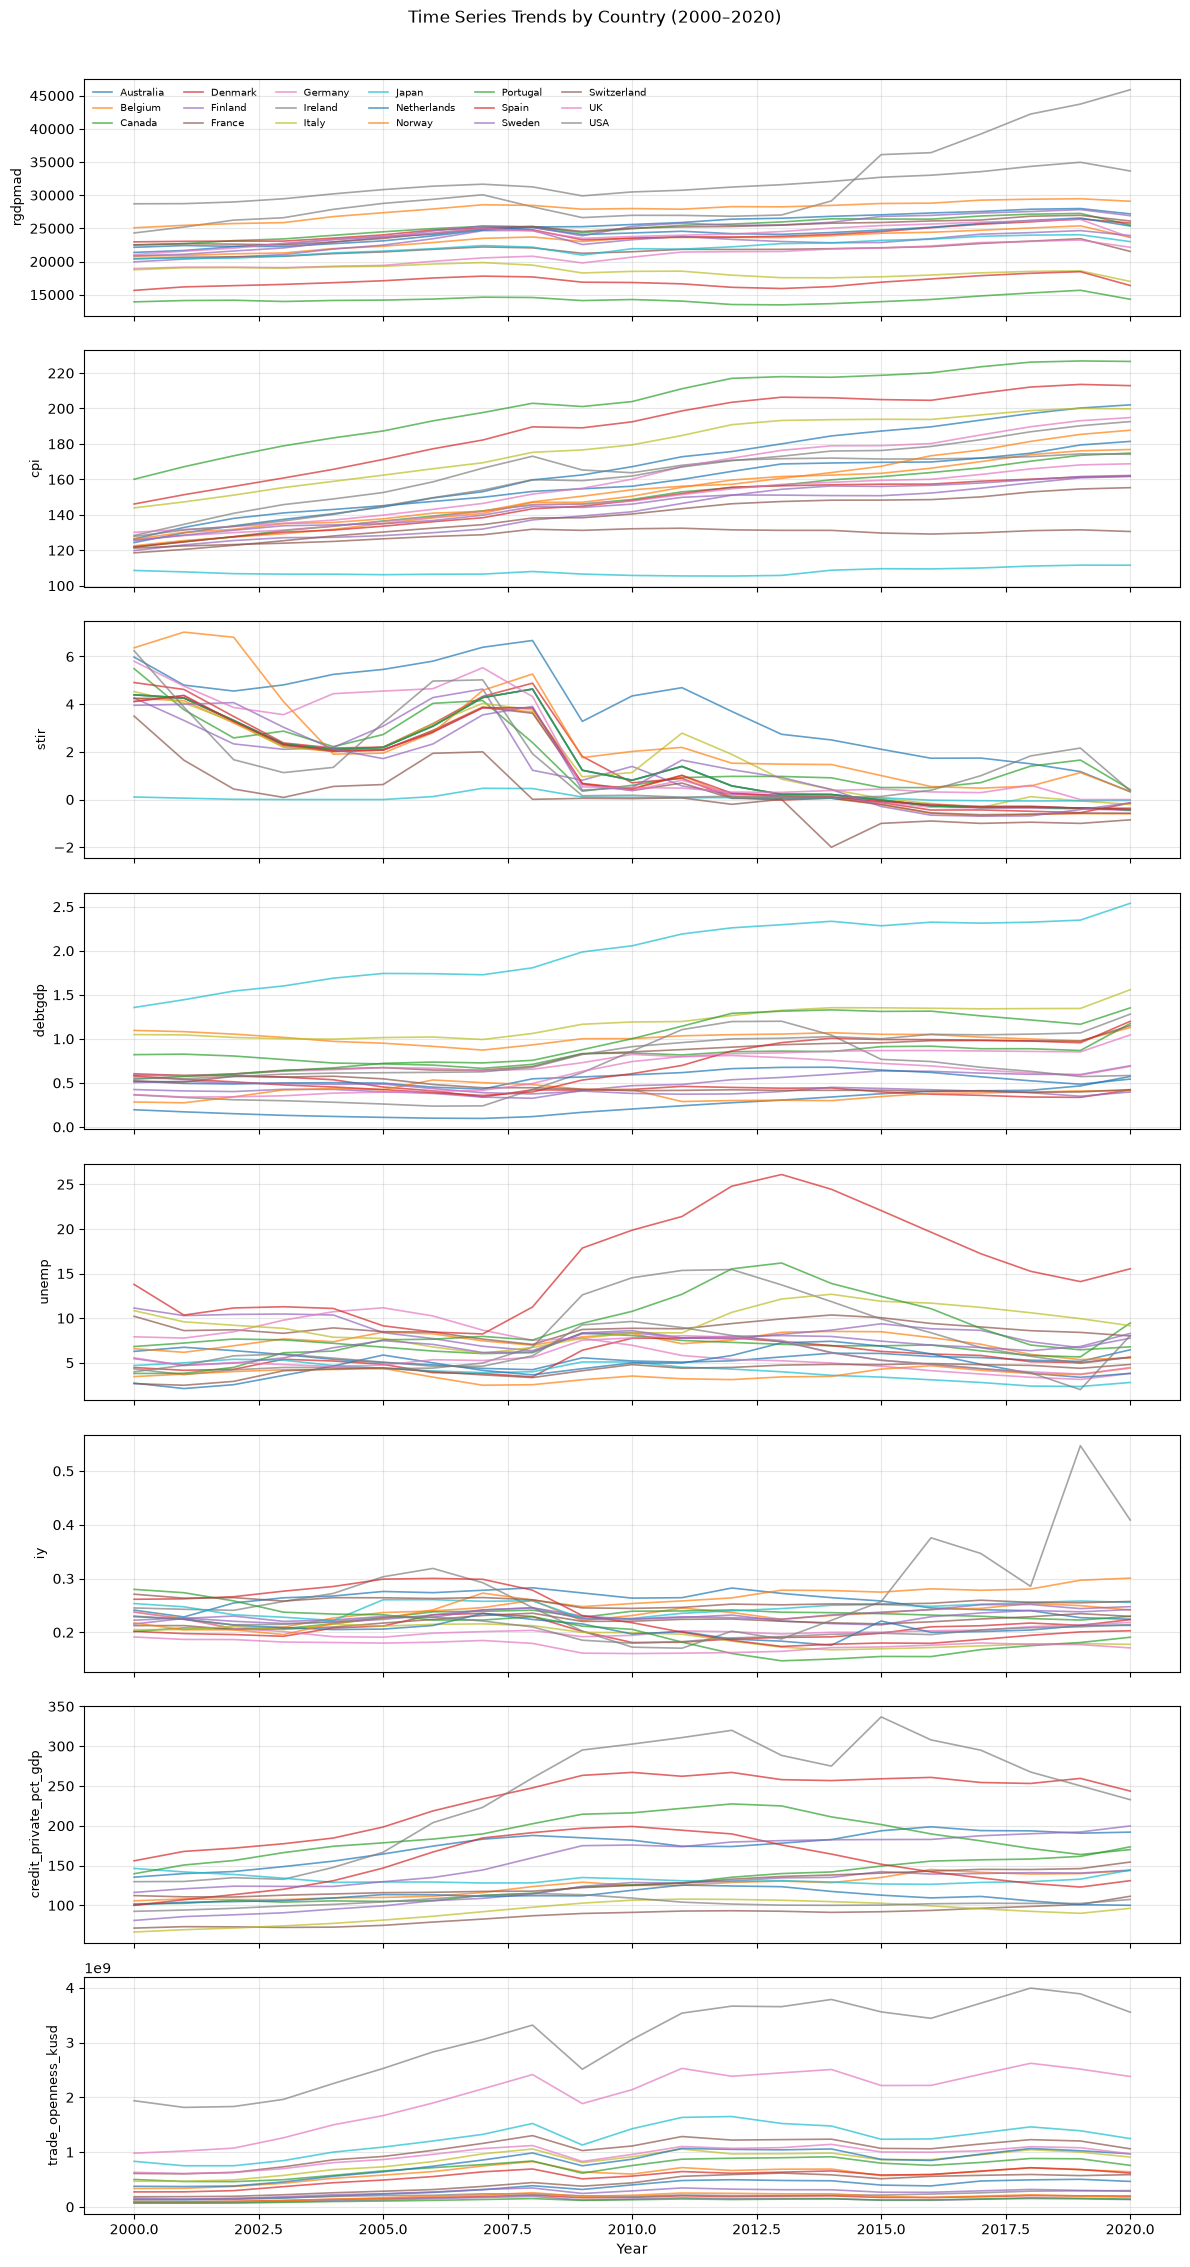

Saved → D:\univercity\omid_project\economics_project\outputs\phase3\figures\time_series_trends.png

--- Country mean ranking (sample) ---
              rgdpmad  debtgdp  unemp  credit_private_pct_gdp   export_kusd  trade_openness_kusd
country                                                                                         
USA          31399.50     0.84   5.91                  103.26  1.162830e+09         3.042575e+09
Ireland      31132.48     0.61   7.93                  238.59  1.389210e+08         2.140262e+08
Norway       27842.75     0.38   3.69                     NaN  1.142427e+08         1.863214e+08
Australia    25270.27     0.26   5.53                  174.76  1.822371e+08         3.491481e+08
Canada       25146.54     0.83   7.05                  128.96  3.715892e+08         7.289197e+08
Sweden       24883.39     0.43   6.94                  160.96  1.393006e+08         2.665408e+08
Switzerland  24804.15     0.46   4.18                  127.85  2.195561e+08         4.

In [4]:
# Phase 3 – EDA | Cell 4: Time Series Trends by Country

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_FIG = PROJECT / "outputs" / "phase3" / "figures"
OUT_TAB = PROJECT / "outputs" / "phase3" / "tables"

print("=" * 60)
print("Phase 3 – EDA | Cell 4: Time Series Trends")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl")
panel = panel.sort_values(["country", "year"])

trend_vars = [c for c in [
    "rgdpmad", "cpi", "stir", "debtgdp", "unemp", "iy",
    "credit_private_pct_gdp", "trade_openness_kusd"
] if c in panel.columns]

n = len(trend_vars)
fig, axes = plt.subplots(n, 1, figsize=(12, 2.8 * n), sharex=True)
if n == 1:
    axes = [axes]

for ax, var in zip(axes, trend_vars):
    for country, g in panel.groupby("country"):
        ax.plot(g["year"], g[var], alpha=0.7, linewidth=1.2, label=country)
    ax.set_ylabel(var, fontsize=9)
    ax.grid(True, alpha=0.3)

axes[0].legend(ncol=6, fontsize=7, loc="upper left", frameon=False)
axes[-1].set_xlabel("Year")
fig.suptitle("Time Series Trends by Country (2000–2020)", y=1.01)
plt.tight_layout()
fig.savefig(OUT_FIG / "time_series_trends.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved → {OUT_FIG / 'time_series_trends.png'}")

# Country ranking snapshot (mean levels)
rank_cols = [c for c in ["rgdpmad", "debtgdp", "unemp", "credit_private_pct_gdp",
                         "export_kusd", "trade_openness_kusd"] if c in panel.columns]
ranking = panel.groupby("country")[rank_cols].mean().sort_values("rgdpmad", ascending=False)
ranking.to_csv(OUT_TAB / "country_mean_ranking.csv")
print("\n--- Country mean ranking (sample) ---")
print(ranking.head(10).round(2).to_string())

print("\nCell 4 completed successfully.")

In [5]:
# Phase 3 – EDA | Cell 5: Anomaly Detection

from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

PROJECT = Path(r"D:\univercity\omid_project\economics_project")
OUT_DATA = PROJECT / "outputs" / "phase3" / "data"
OUT_TAB  = PROJECT / "outputs" / "phase3" / "tables"

print("=" * 60)
print("Phase 3 – EDA | Cell 5: Anomaly Detection")
print("=" * 60)

panel = pd.read_pickle(PROJECT / "outputs" / "phase2" / "data" / "panel_final_clean.pkl").copy()

feat_cols = [c for c in [
    "rgdpmad", "cpi", "stir", "debtgdp", "unemp", "iy",
    "tloans", "credit_private_pct_gdp", "export_kusd", "import_kusd"
] if c in panel.columns]

work = panel.dropna(subset=feat_cols).copy()
print(f"Observations used: {len(work)}")

X = StandardScaler().fit_transform(work[feat_cols])
iso = IsolationForest(n_estimators=300, contamination=0.03, random_state=42)
work["anomaly_flag"] = (iso.fit_predict(X) == -1).astype(int)

n_anom = int(work["anomaly_flag"].sum())
print(f"Detected anomalies: {n_anom} ({100*n_anom/len(work):.2f}%)")

print("\n--- Sample anomalies ---")
cols_show = ["year", "country"] + feat_cols
print(work.loc[work["anomaly_flag"] == 1, cols_show].head(15).to_string(index=False))

# merge flag back to full panel
panel = panel.merge(
    work[["year", "country", "anomaly_flag"]],
    on=["year", "country"], how="left"
)
panel["anomaly_flag"] = panel["anomaly_flag"].fillna(0).astype(int)

work.loc[work["anomaly_flag"] == 1, cols_show].to_csv(OUT_TAB / "detected_anomalies.csv", index=False)
panel.to_pickle(OUT_DATA / "panel_with_anomaly_flag.pkl")
panel.to_csv(OUT_TAB / "panel_with_anomaly_flag.csv", index=False)

print(f"\nSaved anomalies + flagged panel")
print("\nCell 5 completed successfully.")
print("PHASE 3 COMPLETED.")

Phase 3 – EDA | Cell 5: Anomaly Detection
Observations used: 315
Detected anomalies: 10 (3.17%)

--- Sample anomalies ---
 year country      rgdpmad        cpi      stir  debtgdp   unemp       iy       tloans  credit_private_pct_gdp  export_kusd  import_kusd
 2019 Ireland 43729.410638 174.369999 -0.356333 0.572149  4.9500 0.546975 1.028614e+05                250.1500 1.959509e+08 9.721127e+07
 2007   Spain 17802.334056 182.202671  3.847500 0.357646  8.2321 0.298622 2.928747e+08                184.6875 2.532761e+08 3.863219e+08
 2008   Spain 17681.914176 189.627782  3.850000 0.397120 11.2545 0.278365 3.111221e+08                191.3375 2.781759e+08 4.134796e+08
 2010   Spain 16840.746529 192.486112  0.453333 0.605153 19.8597 0.217889 3.068075e+08                199.1250 2.443598e+08 3.174257e+08
 2011   Spain 16641.490671 198.638580  1.017500 0.698504 21.3905 0.200218 2.965920e+08                194.3500 2.868207e+08 3.580674e+08
 2012   Spain 16117.770334 203.495899  0.270000 0.863068